In [100]:
import integrator as itg
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kernels

In [101]:
def f_1(x):
    return x

In [102]:
num_traj = 10
x0 = np.random.uniform(0,1,(num_traj,1))
# x0 = np.array([[0.5]])
tstar = np.linspace(0, 1, 101)
t = [tstar for _ in range(num_traj)]
traj = itg.rk4_solver(f_1, x0, t, step_size=0.01)


In [103]:
gamma2 = 0.1
traj_noisy = [traj[k] + np.random.normal(0, np.sqrt(gamma2), traj[k].shape) for k in range(num_traj)]

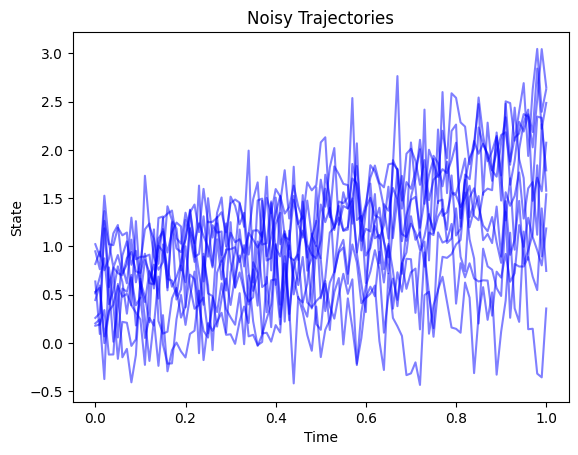

In [104]:
for k in range(num_traj):
    plt.plot(tstar, traj_noisy[k], color='blue', alpha=0.5)
plt.xlabel('Time')
plt.ylabel('State')
plt.title('Noisy Trajectories')
plt.savefig('pictures/noisy_trajectories.pdf')

In [105]:
from importlib import reload
kernels = reload(kernels)
traj_concat = np.concatenate(traj_noisy, axis=0)
bw = np.std(traj_concat) # * (4 / (3 * traj_concat.shape[0]))**0.2
bw = 1.0
print(f"Bandwidth: {bw}")
kernel = lambda x, y: kernels.linear_kernel(x, y)
x_kernel = lambda x, y: kernels.exp_dot_kernel(x, y, bw=bw)

Bandwidth: 1.0


In [106]:
def get_gram_matrix(t, traj_latent, kernel):
    N = traj_latent[0].shape[0]
    traj_concat = np.concatenate(traj_latent, axis=0)
    K = np.array(kernel(traj_concat, traj_concat))
    num_traj = len(traj_latent)
    idx = np.arange(N,K.shape[0], step=N)
    K = K[1:] + K[:-1]
    K = K[:,1:] + K[:,:-1]
    K = np.delete(K, idx, axis=0)
    K = np.delete(K, idx, axis=1)
    delta_t = t[0][1:] - t[0][:-1]
    Delta_t = np.tile(delta_t, (num_traj,))
    K = K*Delta_t[:, None]/2.0*Delta_t[None, :]/2.0
    # K = np.cumsum(K, axis=0)
    # K = np.cumsum(K, axis=1)
    # K = K[1:, 1:]
    for i in range(num_traj):
        for j in range(num_traj):
            K[i*(N-1):(i+1)*(N-1), j*(N-1):(j+1)*(N-1)] = np.cumsum(np.cumsum(K[i*(N-1):(i+1)*(N-1), j*(N-1):(j+1)*(N-1)], axis=0), axis=1)
    return K

In [107]:
def get_occ_kerns(x, t, traj_latent, kernel):
    N = traj_latent[0].shape[0]
    traj_concat = np.concatenate(traj_latent, axis=0)
    K = np.array(kernel(x, traj_concat))
    num_traj = len(traj_latent)
    K = K[:,1:] + K[:,:-1]
    idx = np.arange(N,K.shape[1], step=N)
    K = np.delete(K, idx, axis=1)
    #K[:, idx] = 0
    delta_t = t[0][1:] - t[0][:-1]
    Delta_t = np.tile(delta_t, (num_traj,))
    K = K * Delta_t[None, :]/2.0
    # K = np.cumsum(K, axis=1)
    #K = K[:, 1:]
    # K[:, idx] = 0.0
    for i in range(num_traj):
        K[:, i*(N-1):(i+1)*(N-1)] = np.cumsum(K[:, i*(N-1):(i+1)*(N-1)], axis=1)
    return K

In [108]:
def compute_y_var(K_gram, gamma2):
    return K_gram + gamma2 * np.eye(K_gram.shape[0])

In [109]:
def compute_posterior_mean(x, t, traj_latent, y_var, kernel, x0):
    K_x = get_occ_kerns(x, t, traj_latent, kernel)
    traj_skip = [traj_latent[k][1:] for k in range(len(traj_latent))]
    traj_concat = np.concatenate(traj_skip, axis=0)
    mean = K_x @ np.linalg.solve(y_var, traj_concat - x0[:, None])
    return mean

In [110]:
def compute_posterior_covar(x, y, t, traj_latent, y_var, kernel):
    K_xy = kernel(x, y)
    K_x = get_occ_kerns(x, t, traj_latent, kernel)
    K_y = get_occ_kerns(y, t, traj_latent, kernel)
    covar = K_xy - K_x @ np.linalg.solve(y_var, K_y.T)
    return covar

In [111]:
def get_xy_covar(s, t, x_kernel, x0_var):
    s_low = float(s[0])
    s_high = float(s[-1])
    h = t[1] - t[0]
    sstar = np.arange(s_low, s_high + h, h)
    K = x_kernel(sstar[:, None], t[:, None])
    K = K[1:] + K[:-1]
    K = K[:,1:] + K[:,:-1]
    N = t.shape[0]
    delta_t = t[1:] - t[:-1]
    num_traj = len(t)
   
    delta_s = sstar[1:] - sstar[:-1]
    # Delta_s = np.tile(delta_s, (num_traj,))
    K = K * delta_t[None, :]/2.0 * delta_s[:, None]/2.0
    K = np.cumsum(K, axis=0)
    K = np.cumsum(K, axis=1)
    s_idx = np.argmin(np.abs(sstar - s[:, None]), axis=1)
    K_final = np.insert(K, 0, 0.0, axis=0)
    K_final = K[s_idx, :]
    x0_var_mat = np.ones(K_final.shape)*x0_var
    return K_final + x0_var_mat

In [112]:
def get_yy_covar(t, x_kernel, x0_var):
    N = t.shape[0]
    K = x_kernel(t[:, None], t[:, None])
    K = K[1:] + K[:-1]
    K = K[:,1:] + K[:,:-1]
    delta_t = t[1:] - t[:-1]
    K = K*delta_t[:, None]/2.0*delta_t[None, :]/2.0
    K = np.cumsum(K, axis=0)
    K = np.cumsum(K, axis=1)
    x0_var_mat = np.ones(K.shape)*x0_var
    return K + x0_var_mat

In [113]:
def get_xx_covar(t, x_kernel, x0_var):
    N = t.shape[0]
    K = x_kernel(t[:, None], t[:, None])
    K = K[1:] + K[:-1]
    K = K[:,1:] + K[:,:-1]
    delta_t = t[1:] - t[:-1]
    K = K*delta_t[:, None]/2.0*delta_t[None, :]/2.0
    K = np.cumsum(K, axis=0)
    K = np.cumsum(K, axis=1)
    K = np.insert(K, 0, 0.0, axis=0)
    K = np.insert(K, 0, 0.0, axis=1)
    x0_var_mat = np.ones(K.shape)*x0_var
    return K + x0_var_mat

In [114]:
def sample_traj_latent(idx, t, traj_noisy, x_kernel, gamma2, x0_mean, x0_var,num_samples=1, eps=1e-6):
   t_idx = t[idx]
   K_yy = get_yy_covar(t_idx, x_kernel, x0_var)
   K_xy = get_xy_covar(t_idx, t_idx, x_kernel, x0_var)
   K_xx = get_xx_covar(t_idx, x_kernel, x0_var)
   y_obs = traj_noisy[idx]
   mu_post = x0_mean + K_xx @ np.linalg.solve(K_xx + gamma2 * np.eye(K_xx.shape[0]), y_obs - x0_mean)
   covar_post = K_xx - K_xx@ np.linalg.solve(K_xx + gamma2 * np.eye(K_xx.shape[0]), K_xx.T)
   covar_post = 0.5 * (covar_post + covar_post.T) # Ensure symmetry
    # Add jitter for numerical stability
   covar_post += eps * np.eye(covar_post.shape[0])
   samples = np.random.multivariate_normal(mu_post.flatten(),covar_post, size=num_samples)
   return samples

In [115]:
def sample_latent_traj_all(t, traj_noisy, x_kernel, gamma2, x0_var, num_samples=1, eps=1e-6):
    num_traj = len(traj_noisy)
    traj_latent_samples = []
    for k in range(num_traj):
        x0_mean = traj_noisy[k][0]
        samples = sample_traj_latent(k, t, traj_noisy, x_kernel, gamma2, x0_mean, x0_var, num_samples, eps)
        traj_latent_samples.append(samples)
    traj_latent_samples = [[traj_latent_samples[k][n][:, None] for k in range(num_traj)] for n in range(num_samples)]
    return traj_latent_samples

In [116]:
traj_latent = sample_latent_traj_all(t, traj_noisy, x_kernel, gamma2, x0_var=0.1, num_samples=100)

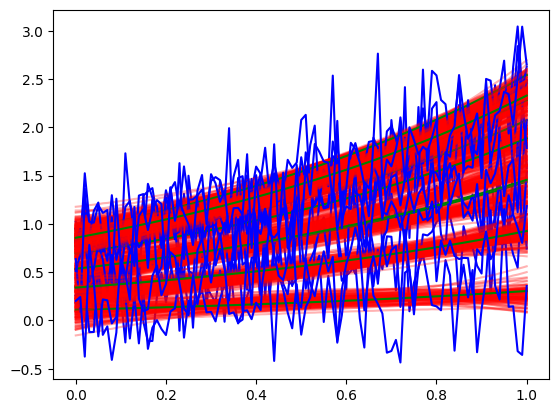

In [117]:
#traj_latent = sample_traj_latent(6, t, traj_noisy, x_kernel, gamma2, x0_mean=traj_noisy[6][0], x0_var=0.1, num_samples=100)
for k in range(len(traj_latent[0])):
    for l in range(len(traj_latent)):
        plt.plot(t[k], traj_latent[l][k].flatten(), color='red', label='Inferred Latent Trajectory', alpha=0.3)
    plt.plot(t[k], traj[k], color='green', label='True Trajectory')
    plt.plot(t[k], traj_noisy[k], color='blue', label='Noisy Observations')

In [118]:
def compute_posterior_mean(x, t, traj, y_var, kernel, x0):
    K_x = get_occ_kerns(x, t, traj, kernel)
    traj_skip = [traj[k][1:] for k in range(len(traj))]
    traj_concat = np.concatenate(traj_skip, axis=0)
    mean = K_x @ np.linalg.solve(y_var, traj_concat - x0)
    return mean

In [119]:
def compute_posterior_covar(x, y, t, traj, y_var, kernel):
    K_xy = kernel(x, y)
    K_x = get_occ_kerns(x, t, traj, kernel)
    K_y = get_occ_kerns(y, t, traj, kernel)
    covar = K_xy - K_x @ np.linalg.solve(y_var, K_y.T)
    return covar

In [120]:
def compute_true_posterior_mean(x, t, traj_latent, kernel, gamma2):
    num_samples = len(traj_latent)
    num_traj = len(traj_latent[0])
    posterior_mean = []
    for k in range(num_samples):
        x0 = np.array([np.tile(traj_latent[k][j][0], (traj_latent[k][j].shape[0]-1, 1)) for j in range(num_traj)])
        x0 = np.concatenate(x0, axis=0)
        gram_mat_k = get_gram_matrix(t, traj_latent[k], kernel)
        y_var = compute_y_var(gram_mat_k, gamma2)
        posterior_mean.append(compute_posterior_mean(x, t, traj_latent[k], y_var, kernel, x0))
    posterior_mean = np.stack(posterior_mean, axis=0)
    return np.mean(posterior_mean, axis=0)


In [121]:
def compute_true_posterior_covar(x,y, t, traj_latent, kernel, gamma2):
    num_samples = len(traj_latent)
    num_traj = len(traj_latent[0])
    posterior_covar = []
    for k in range(num_samples):
        gram_mat_k = get_gram_matrix(t, traj_latent[k], kernel)
        y_var = compute_y_var(gram_mat_k, gamma2)
        posterior_covar.append(compute_posterior_covar(x, y, t, traj_latent[k], y_var, kernel))
    posterior_covar = np.stack(posterior_covar, axis=0)
    return np.mean(posterior_covar, axis=0)

In [122]:
x0 = np.array([np.tile(traj_noisy[j][0], (traj_noisy[j].shape[0]-1, 1)) for j in range(num_traj)])
x0 = np.concatenate(x0, axis=0)
K_gram = get_gram_matrix(t, traj_noisy, kernel)
y_var = compute_y_var(K_gram, gamma2)

In [123]:
mu2 = lambda x: compute_posterior_mean(x, t, traj_noisy, y_var, kernel, x0 = x0)
covar2 = lambda x, y: compute_posterior_covar(x, y, t, traj_noisy, y_var, kernel)

In [127]:
mu = lambda x: compute_true_posterior_mean(x, t, traj_latent, kernel, np.sqrt(gamma2))
covar = lambda x, y: compute_true_posterior_covar(x, y, t, traj_latent, kernel, np.sqrt(gamma2))

In [128]:
traj_concat = np.concatenate(traj_noisy, axis=0)
low_x = np.min(traj_concat)-1.0
high_x = np.max(traj_concat)+1.0
xstar = np.linspace(low_x, high_x, 100)
mu_xstar = mu(xstar[:, None])
f_xstar = f_1(xstar[:, None])
covar_xstar_full = covar(xstar[:, None], xstar[:, None])
std_xstar = np.sqrt(np.diag(covar_xstar_full))
err_xstar = 1.96 * std_xstar
mu_xstar = mu_xstar[:, 0]


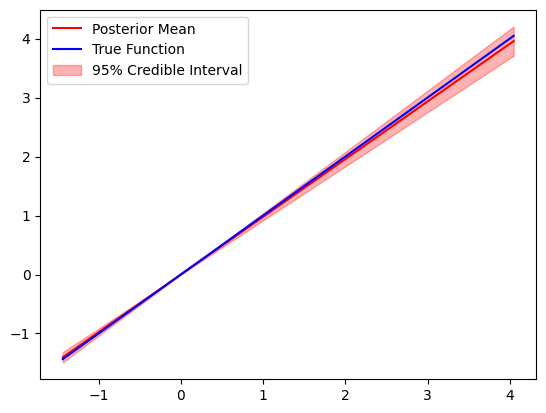

In [130]:
plt.plot(xstar, mu_xstar, color='red', label='Posterior Mean')
plt.plot(xstar, f_xstar, color='blue', label='True Function')
plt.fill_between(xstar, mu_xstar - err_xstar, mu_xstar + err_xstar, color='red', alpha=0.3, label='95% Credible Interval')
plt.legend()
plt.savefig('pictures/posterior_function_estimate.pdf')